In [21]:
import sys
sys.path.append("../scripts")
import reinforce as rf
import rl
import lib
import random
import torch
from sklearn.model_selection import train_test_split


## Global Parameters

`GAMMA` refers to the reinforcement learning delay discounting parameter, while `GAMMA_LAPSE` refers to human attentional limits for traversing a tree. 

In [22]:
GAMMA = 0.99
AND_OR_GUIDANCE = True
AND_OR_GAMMA_LAPSE = 0.1
GUIDANCE_SCALE = 1.0
HEURISTIC_CONFIDENCE_THRESHOLD = 0.5
ENTROPY_COEF = 0.01
DISTANCE_WEIGHT_CAP = 3.0

In [23]:
SPLIT_SEED = 0
TRAIN_SIZE = 0.9

## Loading Data

In [24]:
puzzles = lib.read_puzzles("../data/rush_nw_cluster.txt")

In [25]:
all_puzzles = [puzzle for dist in sorted(puzzles) for puzzle in puzzles[dist]]
all_distances = [dist for dist in sorted(puzzles) for puzzle in puzzles[dist]]

train_puzzles, test_puzzles, train_distances, test_distances = train_test_split(
    all_puzzles, all_distances, train_size=TRAIN_SIZE, random_state=SPLIT_SEED
)

## REINFORCE + And-Or Learning

In [26]:
random.seed(3)
torch.manual_seed(0)

trainer = rf.ReinforceTrainer(train_puzzles, test_puzzles, (6, 6),
                               train_distances=train_distances, test_distances=test_distances, gamma=GAMMA,
                               and_or_guidance=AND_OR_GUIDANCE, and_or_gamma=AND_OR_GAMMA_LAPSE,
                               guidance_scale=GUIDANCE_SCALE,
                               heuristic_confidence_threshold=HEURISTIC_CONFIDENCE_THRESHOLD)
policy_loss, train_results, test_results = trainer.train(
    n_iterations=100, max_steps=50, eval_every=2,
    entropy_coef=ENTROPY_COEF, distance_weight_cap=DISTANCE_WEIGHT_CAP
)
print(f"policy_loss={policy_loss:.3f}")
print(f"train_results={train_results}")
print(f"test_results={test_results}")

REINFORCE iterations:   0%|          | 0/100 [00:00<?, ?it/s]

REINFORCE iterations: 100%|██████████| 100/100 [02:08<00:00,  1.29s/it, guided=0%, loss=0.151, sampled=12/14] 


policy_loss=0.151
train_results=[(True, 14), (True, 14), (True, 17), (True, 13), (True, 13), (True, 17), (True, 15), (True, 24), (True, 17), (True, 17), (True, 15), (False, nan), (True, 14), (True, 14)]
test_results=[(True, 12), (True, 20)]


In [27]:
import os
os.makedirs("../models", exist_ok=True)
trainer.agent.save("../models/reinforce_agent.pt")

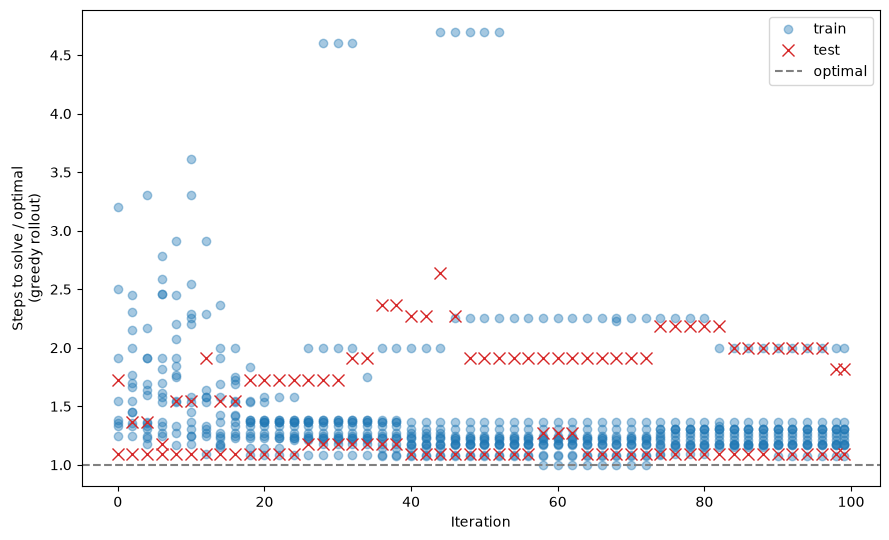

In [28]:
import matplotlib.pyplot as plt

iterations = [it for it, _, _ in trainer.history]

plt.figure(figsize=(9, 5.5))
for i in range(len(train_puzzles)):
    steps = [train_i[i][1] / train_distances[i] for _, train_i, _ in trainer.history]
    plt.plot(iterations, steps, marker="o", linestyle="None", color="tab:blue", alpha=0.4,
              label="train" if i == 0 else None)
for i in range(len(test_puzzles)):
    steps = [test_i[i][1] / test_distances[i] for _, _, test_i in trainer.history]
    plt.plot(iterations, steps, marker="x", linestyle="None", color="tab:red", markersize=8,
              label="test" if i == 0 else None)
plt.axhline(1.0, color="gray", linestyle="--", label="optimal")
plt.xlabel("Iteration"); plt.ylabel("Steps to solve / optimal\n(greedy rollout)")
plt.legend()
plt.tight_layout()
plt.savefig("../visualization/reinforce_bc.png")
plt.show()

## Fine-tuning convergence: pretrained vs. scratch

In [29]:
FT_KWARGS = dict(n_iterations=30, max_steps=200, eval_every=1, gamma=GAMMA)

FT_TEST_SIZE = 5
ft_test_puzzles = test_puzzles[:FT_TEST_SIZE]
ft_test_distances = test_distances[:FT_TEST_SIZE]

pretrained_curves, scratch_curves = [], []
for i, puzzle in enumerate(ft_test_puzzles):
    random.seed(100 + i); torch.manual_seed(100 + i)
    pretrained_curves.append(rf.finetune_curve(
        rf.ReinforceAgent.load("../models/reinforce_agent.pt", and_or_guidance=AND_OR_GUIDANCE,
                                and_or_gamma=AND_OR_GAMMA_LAPSE, guidance_scale=GUIDANCE_SCALE,
                                heuristic_confidence_threshold=HEURISTIC_CONFIDENCE_THRESHOLD),
        puzzle, (6, 6), desc=f"pretrained {i + 1}/{len(ft_test_puzzles)}", **FT_KWARGS))

    random.seed(100 + i); torch.manual_seed(100 + i)
    scratch_curves.append(rf.finetune_curve(
        rf.ReinforceAgent((6, 6), and_or_guidance=AND_OR_GUIDANCE,
                           and_or_gamma=AND_OR_GAMMA_LAPSE, guidance_scale=GUIDANCE_SCALE,
                           heuristic_confidence_threshold=HEURISTIC_CONFIDENCE_THRESHOLD),
        puzzle, (6, 6), desc=f"scratch {i + 1}/{len(ft_test_puzzles)}", **FT_KWARGS))

scratch 2/2: 100%|██████████| 30/30 [00:06<00:00,  4.43it/s, guided=0%, loss=-0.000, sampled=0/1]  


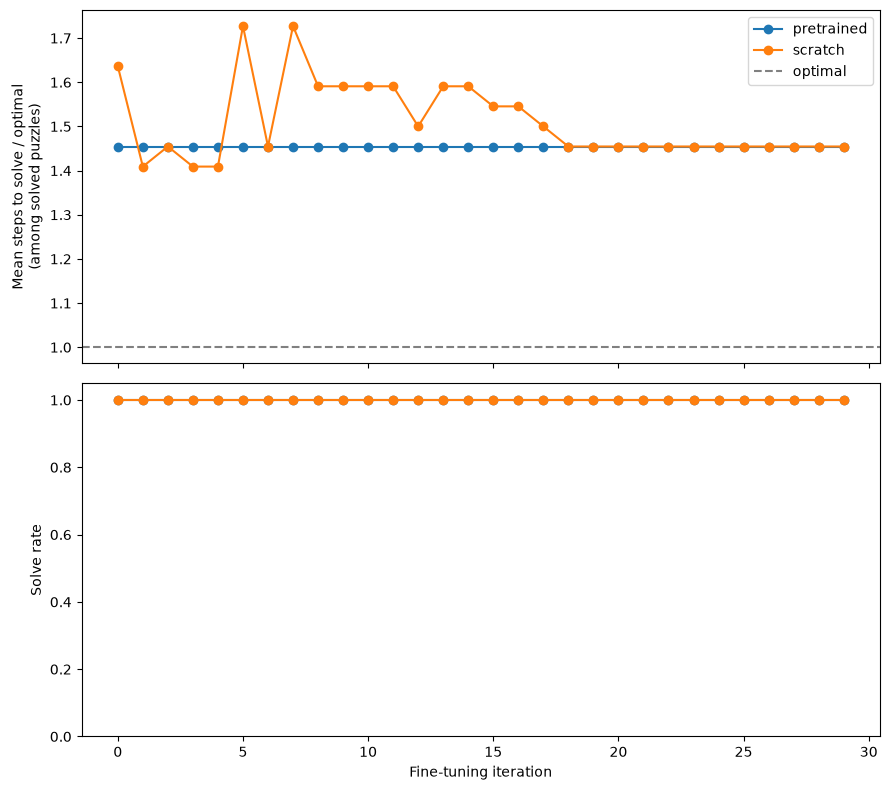

In [30]:
pre_epochs, pre_steps, pre_rate = rl.average_curves(pretrained_curves, optimal=ft_test_distances)
scr_epochs, scr_steps, scr_rate = rl.average_curves(scratch_curves, optimal=ft_test_distances)

fig, (ax_steps, ax_rate) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_steps.plot(pre_epochs, pre_steps, marker="o", color="tab:blue", label="pretrained")
ax_steps.plot(scr_epochs, scr_steps, marker="o", color="tab:orange", label="scratch")
ax_steps.axhline(1.0, color="gray", linestyle="--", label="optimal")
ax_steps.set_ylabel("Mean steps to solve / optimal\n(among solved puzzles)")
ax_steps.legend()

ax_rate.plot(pre_epochs, pre_rate, marker="o", color="tab:blue", label="pretrained")
ax_rate.plot(scr_epochs, scr_rate, marker="o", color="tab:orange", label="scratch")
ax_rate.set_ylim(0, 1.05)
ax_rate.set_xlabel("Fine-tuning iteration")
ax_rate.set_ylabel("Solve rate")

plt.tight_layout()
plt.savefig("../visualization/reinforce_finetune_convergence.png")
plt.show()